# E11 and NIW Pending-Outcome Forecast

This notebook combines the two main analysis tables in the project:

1. **Yearly actual/historic snapshots** for `EB1` and `EB2`.
2. **Quarterly RADP data** for `E11`, `NIW`, and their parent groups.

The objective is to estimate how current pending inventory may eventually split into approvals and denials for E11 and NIW.

The method is deliberately transparent:

- yearly `actual -> historic` changes estimate how parent-category pending cases matured;
- quarterly E11/NIW data estimates how each target program differs from its parent group;
- the two components are combined into a time-varying pending-denial index.

This is an aggregate forecasting exercise. It does not track individual petitions and does not observe RFE directly.

In [1]:
import importlib.util
import subprocess
import sys

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "statsmodels": "statsmodels",
}

missing = [pip_name for import_name, pip_name in required.items() if importlib.util.find_spec(import_name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats
import statsmodels.api as sm

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "analysis_tables").exists():
    raise FileNotFoundError("Run the notebook from the project root.")

ANALYSIS_DIR = PROJECT_ROOT / "data" / "analysis_tables"
RADP_PATH = ANALYSIS_DIR / "eb1eb2_total_radp.csv"
YEARLY_PATH = ANALYSIS_DIR / "i140_yearly_total_eb1_eb2_snapshots.csv"

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\kelav\OneDrive\Документы\projects\uscis_analysis


## 1. Load and audit the two working tables

The quarterly RADP table is valuable because it contains direct E11 and NIW rows. The yearly table is valuable because it contains a longer maturation history for the parent categories EB1 and EB2.

Definitions used throughout the notebook:

- `actual`: the last same-year observation available for a fiscal year, normally Q4; FY2026 is Q1 RADP.
- `historic`: the latest later snapshot available for that fiscal-year cohort.
- `decided`: `approved + denied`.
- `denial odds`: `denied / approved`.
- `denial share`: `denied / (approved + denied)`.

In [2]:
radp = pd.read_csv(RADP_PATH)
yearly = pd.read_csv(YEARLY_PATH)

radp["period"] = pd.PeriodIndex(
    radp["fiscal_year"].astype(str) + "Q" + radp["fiscal_quarter"].astype(str),
    freq="Q-SEP",
)
radp["period_label"] = radp["fiscal_year"].astype(str) + " Q" + radp["fiscal_quarter"].astype(str)

for df in (radp, yearly):
    df["decided"] = df["approved"] + df["denied"]
    df["approval_share_decided"] = np.where(df["decided"] > 0, df["approved"] / df["decided"], np.nan)
    df["denial_share_decided"] = np.where(df["decided"] > 0, df["denied"] / df["decided"], np.nan)
    df["denial_approval_ratio"] = np.where(df["approved"] > 0, df["denied"] / df["approved"], np.nan)

audit = pd.DataFrame({
    "table": ["RADP quarterly", "Yearly snapshots"],
    "rows": [len(radp), len(yearly)],
    "min_fy": [radp.fiscal_year.min(), yearly.fiscal_year.min()],
    "max_fy": [radp.fiscal_year.max(), yearly.fiscal_year.max()],
    "types": [", ".join(sorted(radp.type.unique())), ", ".join(sorted(yearly.type.unique()))],
})
display(audit)

display(
    yearly.groupby(["snapshot_type", "source_report_family"], dropna=False)
    .size().rename("rows").reset_index()
)

,table,rows,min_fy,max_fy,types
0,RADP quarterly,85,2022,2026,"E11, EB1, EB2, NIW, TOTAL"
1,Yearly snapshots,75,2009,2026,"EB1, EB2, TOTAL"


,snapshot_type,source_report_family,rows
0,actual,fy_quarter_status,3
1,actual,preference_country,21
2,historic,preference_country,51


## 2. Reconstruct what happened to parent-category pending inventory

For every year where both `actual` and `historic` exist, the early decided outcomes are removed from the later totals:

```text
new approvals from pending = historic approved - actual approved
new denials from pending   = historic denied   - actual denied
pending reduction          = actual pending    - historic pending
```

The outcome mix of resolved pending is then:

```text
pending denial share = new denials / (new approvals + new denials)
pending denial odds  = new denials / new approvals
```

This is exactly the requested comparison: the historic line does not reuse decisions that were already present in the actual snapshot.

In [3]:
parent_types = ["EB1", "EB2"]

actual = yearly[(yearly["snapshot_type"] == "actual") & yearly["type"].isin(parent_types)].copy()
historic = yearly[(yearly["snapshot_type"] == "historic") & yearly["type"].isin(parent_types)].copy()

maturity = actual.merge(
    historic,
    on=["fiscal_year", "type"],
    suffixes=("_actual", "_historic"),
    validate="one_to_one",
)

for status in ["received", "approved", "denied", "pending"]:
    maturity[f"delta_{status}"] = maturity[f"{status}_historic"] - maturity[f"{status}_actual"]

maturity["actual_decided"] = maturity["approved_actual"] + maturity["denied_actual"]
maturity["actual_approval_share"] = maturity["approved_actual"] / maturity["actual_decided"]
maturity["actual_denial_share"] = maturity["denied_actual"] / maturity["actual_decided"]
maturity["actual_denial_approval_ratio"] = maturity["denied_actual"] / maturity["approved_actual"]

maturity["resolved_from_pending"] = maturity["delta_approved"] + maturity["delta_denied"]
maturity["pending_drop"] = maturity["pending_actual"] - maturity["pending_historic"]
maturity["reconciliation_gap"] = maturity["resolved_from_pending"] - maturity["pending_drop"]
maturity["reconciliation_gap_pct"] = maturity["reconciliation_gap"] / maturity["pending_actual"]

maturity["pending_approval_share"] = maturity["delta_approved"] / maturity["resolved_from_pending"]
maturity["pending_denial_share"] = maturity["delta_denied"] / maturity["resolved_from_pending"]
maturity["pending_denial_approval_ratio"] = maturity["delta_denied"] / maturity["delta_approved"]

cols = [
    "fiscal_year", "type",
    "approved_actual", "denied_actual", "pending_actual",
    "delta_approved", "delta_denied", "pending_drop",
    "reconciliation_gap", "actual_denial_share", "pending_denial_share",
    "actual_denial_approval_ratio", "pending_denial_approval_ratio",
]
display(maturity[cols].sort_values(["type", "fiscal_year"]).style.format({
    "actual_denial_share": "{:.1%}",
    "pending_denial_share": "{:.1%}",
    "actual_denial_approval_ratio": "{:.3f}",
    "pending_denial_approval_ratio": "{:.3f}",
}))

,fiscal_year,type,approved_actual,denied_actual,pending_actual,delta_approved,delta_denied,pending_drop,reconciliation_gap,actual_denial_share,pending_denial_share,actual_denial_approval_ratio,pending_denial_approval_ratio
0,2019,EB1,12268,2531,9371,7042,2224,9307,-41,17.1%,24.0%,0.206,0.316
2,2020,EB1,11758,1975,7674,5663,1913,7607,-31,14.4%,25.3%,0.168,0.338
4,2021,EB1,7778,1343,12899,10697,2082,12779,0,14.7%,16.3%,0.173,0.195
6,2022,EB1,17836,2065,6049,3930,1876,5803,3,10.4%,32.3%,0.116,0.477
8,2023,EB1,24253,2623,10102,6660,2654,8796,518,9.8%,28.5%,0.108,0.398
10,2024,EB1,23954,2517,14693,4798,2510,7078,230,9.5%,34.3%,0.105,0.523
12,2025,EB1,22431,5648,23266,2617,2455,5044,28,20.1%,48.4%,0.252,0.938
1,2019,EB2,65042,1123,12044,8297,3477,11751,23,1.7%,29.5%,0.017,0.419
3,2020,EB2,49010,700,17882,14379,3220,17586,13,1.4%,18.3%,0.014,0.224
5,2021,EB2,42685,324,27541,23296,3841,27088,49,0.8%,14.2%,0.008,0.165


### Reconciliation check

Ideally, the decrease in pending should equal the increase in approvals plus denials. Small gaps are expected because USCIS can revise receipts, categories, or prior counts between releases.

The model is retained only because all approval/denial deltas are positive and the reconciliation gaps are small relative to pending inventory.

In [4]:
reconciliation = maturity[[
    "fiscal_year", "type", "pending_drop", "resolved_from_pending",
    "reconciliation_gap", "reconciliation_gap_pct",
]].sort_values(["type", "fiscal_year"])

display(reconciliation.style.format({"reconciliation_gap_pct": "{:.2%}"}))

assert (maturity[["delta_approved", "delta_denied", "pending_drop"]] >= 0).all().all()
assert maturity["reconciliation_gap_pct"].abs().max() < 0.06
print("All transitions are non-negative; maximum absolute reconciliation gap is",
      f"{maturity['reconciliation_gap_pct'].abs().max():.2%} of actual pending.")

,fiscal_year,type,pending_drop,resolved_from_pending,reconciliation_gap,reconciliation_gap_pct
0,2019,EB1,9307,9266,-41,-0.44%
2,2020,EB1,7607,7576,-31,-0.40%
4,2021,EB1,12779,12779,0,0.00%
6,2022,EB1,5803,5806,3,0.05%
8,2023,EB1,8796,9314,518,5.13%
10,2024,EB1,7078,7308,230,1.57%
12,2025,EB1,5044,5072,28,0.12%
1,2019,EB2,11751,11774,23,0.19%
3,2020,EB2,17586,17599,13,0.07%
5,2021,EB2,27088,27137,49,0.18%


All transitions are non-negative; maximum absolute reconciliation gap is 5.13% of actual pending.


## 3. Actual outcome odds versus outcomes resolved from pending

The requested visual convention is used:

- **solid line**: denial/approval ratio among cases already decided in the actual snapshot;
- **dashed line**: denial/approval ratio only among decisions added between actual and historic snapshots.

The dashed line is therefore the estimated outcome mix of the pending inventory that later resolved.

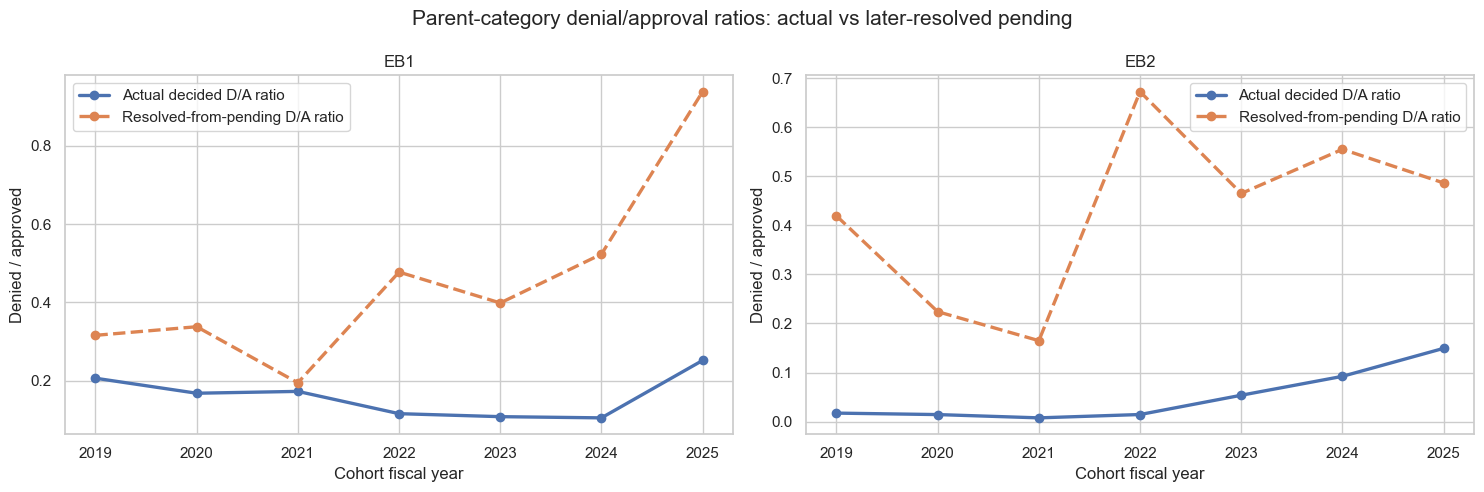

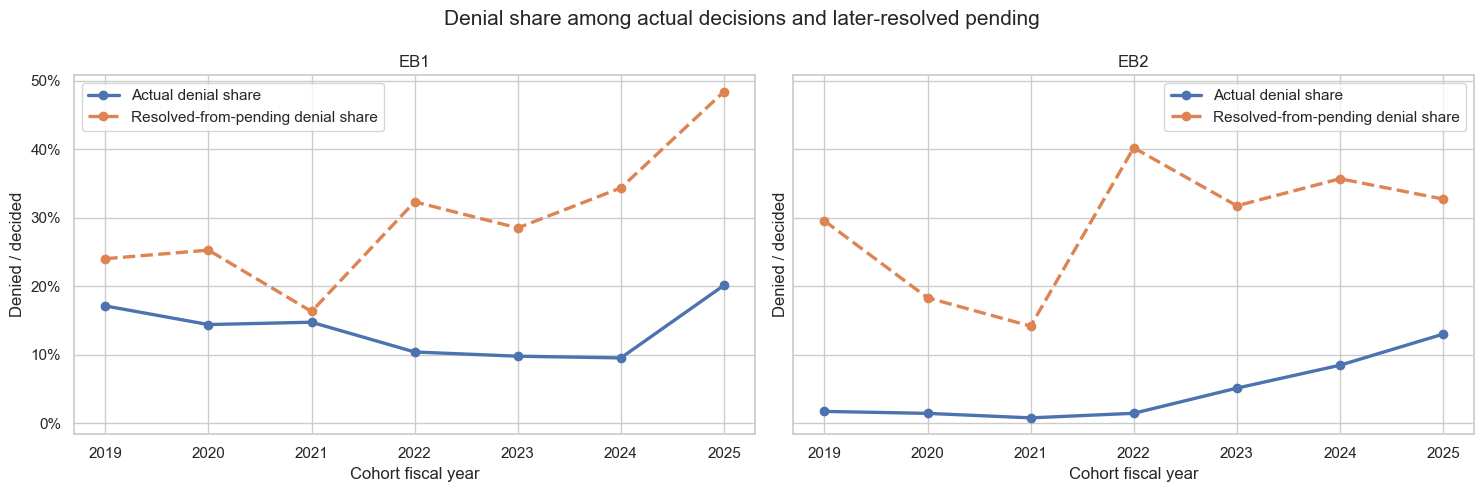

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

for ax, parent in zip(axes, parent_types):
    part = maturity[maturity["type"] == parent].sort_values("fiscal_year")
    ax.plot(part["fiscal_year"], part["actual_denial_approval_ratio"], marker="o", linewidth=2.4,
            label="Actual decided D/A ratio")
    ax.plot(part["fiscal_year"], part["pending_denial_approval_ratio"], marker="o", linewidth=2.4,
            linestyle="--", label="Resolved-from-pending D/A ratio")
    ax.set_title(parent)
    ax.set_xlabel("Cohort fiscal year")
    ax.set_ylabel("Denied / approved")
    ax.legend()

fig.suptitle("Parent-category denial/approval ratios: actual vs later-resolved pending", fontsize=15)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, parent in zip(axes, parent_types):
    part = maturity[maturity["type"] == parent].sort_values("fiscal_year")
    ax.plot(part["fiscal_year"], part["actual_denial_share"], marker="o", linewidth=2.4,
            label="Actual denial share")
    ax.plot(part["fiscal_year"], part["pending_denial_share"], marker="o", linewidth=2.4,
            linestyle="--", label="Resolved-from-pending denial share")
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    ax.set_title(parent)
    ax.set_xlabel("Cohort fiscal year")
    ax.set_ylabel("Denied / decided")
    ax.legend()
fig.suptitle("Denial share among actual decisions and later-resolved pending", fontsize=15)
plt.tight_layout()
plt.show()

## 4. Estimate the parent-category pending correction

Two correction measures are useful:

1. **Additive correction**: pending denial share minus actual denial share.
2. **Odds multiplier**: pending denial odds divided by actual denial odds.

The odds multiplier is preferred for combining parent categories with E11/NIW program differences because odds multiply naturally.

Confidence intervals are computed by resampling fiscal years. With only seven paired years, these intervals are descriptive and should not be interpreted as high-precision inference.

In [6]:
def aggregate_correction(frame):
    actual_a = frame["approved_actual"].sum()
    actual_d = frame["denied_actual"].sum()
    pending_a = frame["delta_approved"].sum()
    pending_d = frame["delta_denied"].sum()
    actual_share = actual_d / (actual_a + actual_d)
    pending_share = pending_d / (pending_a + pending_d)
    actual_odds = actual_d / actual_a
    pending_odds = pending_d / pending_a
    return actual_share, pending_share, pending_share - actual_share, pending_odds / actual_odds

def bootstrap_correction(frame, iterations=5000, seed=42):
    rng = np.random.default_rng(seed)
    values = []
    rows = frame.reset_index(drop=True)
    for _ in range(iterations):
        sample = rows.iloc[rng.integers(0, len(rows), len(rows))]
        values.append(aggregate_correction(sample))
    return np.asarray(values)

correction_rows = []
for parent in parent_types:
    part = maturity[maturity["type"] == parent]
    point = aggregate_correction(part)
    boot = bootstrap_correction(part)
    correction_rows.append({
        "parent": parent,
        "years": len(part),
        "actual_denial_share": point[0],
        "pending_denial_share": point[1],
        "additive_correction_pp": point[2],
        "pending_vs_actual_odds_multiplier": point[3],
        "multiplier_ci_low": np.quantile(boot[:, 3], 0.025),
        "multiplier_ci_high": np.quantile(boot[:, 3], 0.975),
        "pending_share_ci_low": np.quantile(boot[:, 1], 0.025),
        "pending_share_ci_high": np.quantile(boot[:, 1], 0.975),
    })

parent_correction = pd.DataFrame(correction_rows)
display(parent_correction.style.format({
    "actual_denial_share": "{:.1%}",
    "pending_denial_share": "{:.1%}",
    "additive_correction_pp": "{:+.1%}",
    "pending_vs_actual_odds_multiplier": "{:.2f}x",
    "multiplier_ci_low": "{:.2f}x",
    "multiplier_ci_high": "{:.2f}x",
    "pending_share_ci_low": "{:.1%}",
    "pending_share_ci_high": "{:.1%}",
}))

,parent,years,actual_denial_share,pending_denial_share,additive_correction_pp,pending_vs_actual_odds_multiplier,multiplier_ci_low,multiplier_ci_high,pending_share_ci_low,pending_share_ci_high
0,EB1,7,13.5%,27.5%,+14.1%,2.44x,1.66x,3.67x,21.7%,34.9%
1,EB2,7,4.7%,27.6%,+22.8%,7.67x,4.27x,18.96x,20.5%,34.8%


### Statistical checks on actual versus pending-resolved outcomes

The paired Wilcoxon test asks whether the annual pending-resolved denial share is systematically different from the actual denial share.

A simple time-trend regression is also reported for both series. The sample is short, so the p-values are diagnostics rather than definitive proof.

In [7]:
test_rows = []
for parent in parent_types:
    part = maturity[maturity["type"] == parent].sort_values("fiscal_year")
    wilcox = stats.wilcoxon(part["pending_denial_share"], part["actual_denial_share"], alternative="two-sided")
    actual_trend = stats.linregress(part["fiscal_year"], part["actual_denial_share"])
    pending_trend = stats.linregress(part["fiscal_year"], part["pending_denial_share"])
    test_rows.append({
        "parent": parent,
        "paired_years": len(part),
        "wilcoxon_stat": wilcox.statistic,
        "wilcoxon_p": wilcox.pvalue,
        "actual_trend_pp_per_year": actual_trend.slope,
        "actual_trend_p": actual_trend.pvalue,
        "pending_trend_pp_per_year": pending_trend.slope,
        "pending_trend_p": pending_trend.pvalue,
    })

parent_tests = pd.DataFrame(test_rows)
display(parent_tests.style.format({
    "wilcoxon_p": "{:.4f}",
    "actual_trend_pp_per_year": "{:+.2%}",
    "actual_trend_p": "{:.4f}",
    "pending_trend_pp_per_year": "{:+.2%}",
    "pending_trend_p": "{:.4f}",
}))

,parent,paired_years,wilcoxon_stat,wilcoxon_p,actual_trend_pp_per_year,actual_trend_p,pending_trend_pp_per_year,pending_trend_p
0,EB1,7,0.000000,0.0156,-0.20%,0.8175,+3.70%,0.0339
1,EB2,7,0.000000,0.0156,+1.87%,0.0108,+2.21%,0.2425


## 5. Compare target programs with their parent groups in quarterly RADP

Pairs used in the model:

- `E11` compared with `EB1`;
- `NIW` compared with `EB2`.

The descriptive program-parent multiplier is:

```text
(program denied / program approved) / (parent denied / parent approved)
```

For formal quarterly odds-ratio intervals, the target program is compared with the **remainder** of its parent category. This avoids testing a category against a total that contains the same category.

In [8]:
pairs = {"E11": "EB1", "NIW": "EB2"}
quarterly_rows = []

for program, parent in pairs.items():
    program_df = radp[radp["type"] == program].copy()
    parent_df = radp[radp["type"] == parent].copy()
    merged = program_df.merge(
        parent_df,
        on=["fiscal_year", "fiscal_quarter", "period", "period_label"],
        suffixes=("_program", "_parent"),
        validate="one_to_one",
    )
    for _, row in merged.iterrows():
        pa, pdn = row["approved_program"], row["denied_program"]
        ga, gdn = row["approved_parent"], row["denied_parent"]
        ra, rdn = ga - pa, gdn - pdn
        if min(pa, pdn, ra, rdn) <= 0:
            continue
        program_odds = pdn / pa
        parent_odds = gdn / ga
        remainder_odds = rdn / ra
        odds_ratio_remainder = program_odds / remainder_odds
        se_log_or = np.sqrt(1 / pdn + 1 / pa + 1 / rdn + 1 / ra)
        log_or = np.log(odds_ratio_remainder)
        z = log_or / se_log_or
        quarterly_rows.append({
            "program": program,
            "parent": parent,
            "fiscal_year": row["fiscal_year"],
            "fiscal_quarter": row["fiscal_quarter"],
            "period": row["period"],
            "period_label": row["period_label"],
            "approved_program": pa,
            "denied_program": pdn,
            "pending_program": row["pending_program"],
            "approved_parent": ga,
            "denied_parent": gdn,
            "program_denial_share": pdn / (pa + pdn),
            "parent_denial_share": gdn / (ga + gdn),
            "program_odds": program_odds,
            "parent_odds": parent_odds,
            "program_parent_multiplier": program_odds / parent_odds,
            "odds_ratio_vs_remainder": odds_ratio_remainder,
            "or_ci_low": np.exp(log_or - 1.96 * se_log_or),
            "or_ci_high": np.exp(log_or + 1.96 * se_log_or),
            "or_p_value": 2 * stats.norm.sf(abs(z)),
        })

quarterly = pd.DataFrame(quarterly_rows).sort_values(["program", "period"])
display(quarterly.head())
print("Quarterly observations:", quarterly.groupby("program").size().to_dict())

,program,parent,fiscal_year,fiscal_quarter,period,period_label,approved_program,denied_program,pending_program,approved_parent,denied_parent,program_denial_share,parent_denial_share,program_odds,parent_odds,program_parent_multiplier,odds_ratio_vs_remainder,or_ci_low,or_ci_high,or_p_value
0,E11,EB1,2022,1,2022Q1,2022 Q1,1391,492,5925,4671,650,0.2613,0.1222,0.3537,0.1392,2.5418,7.3427,6.0728,8.8781,0.0000
1,E11,EB1,2022,2,2022Q2,2022 Q2,1384,452,6063,4350,580,0.2462,0.1176,0.3266,0.1333,2.4494,7.5677,6.1567,9.3021,0.0000
2,E11,EB1,2022,3,2022Q3,2022 Q3,1493,433,6137,4529,536,0.2248,0.1058,0.2900,0.1183,2.4506,8.5486,6.8356,10.6908,0.0000
3,E11,EB1,2022,4,2022Q4,2022 Q4,1355,231,6281,4168,278,0.1456,0.0625,0.1705,0.0667,2.5560,10.2034,7.4072,14.0550,0.0000
4,E11,EB1,2023,1,2023Q1,2023 Q1,2367,823,6382,7844,1232,0.2580,0.1357,0.3477,0.1571,2.2137,4.6561,4.0967,5.2919,0.0000


Quarterly observations: {'E11': 17, 'NIW': 17}


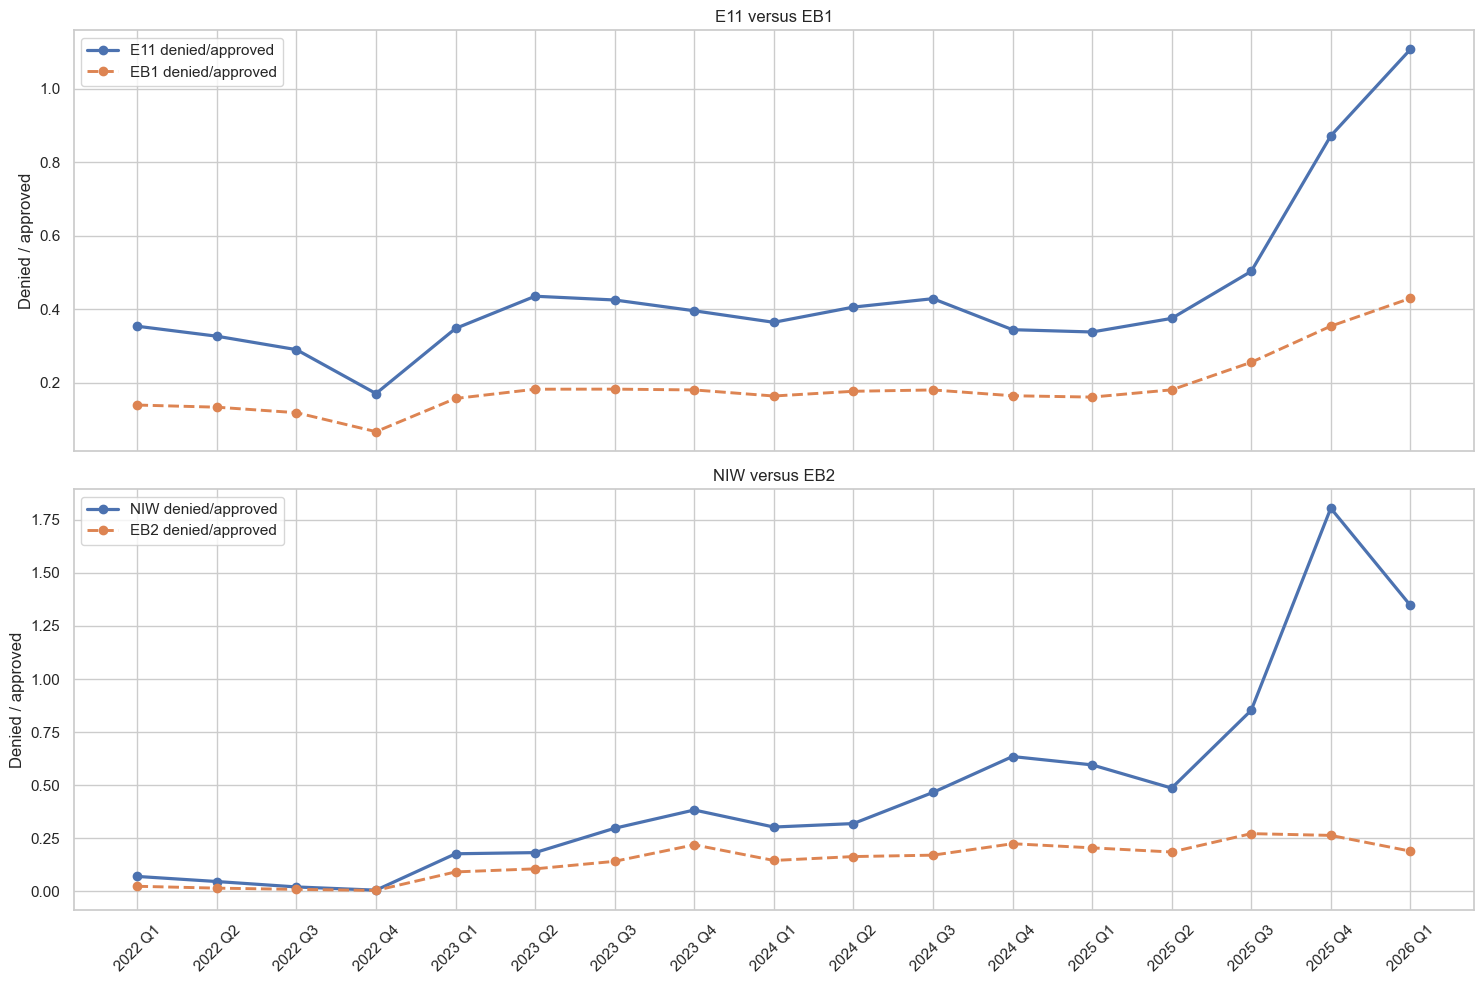

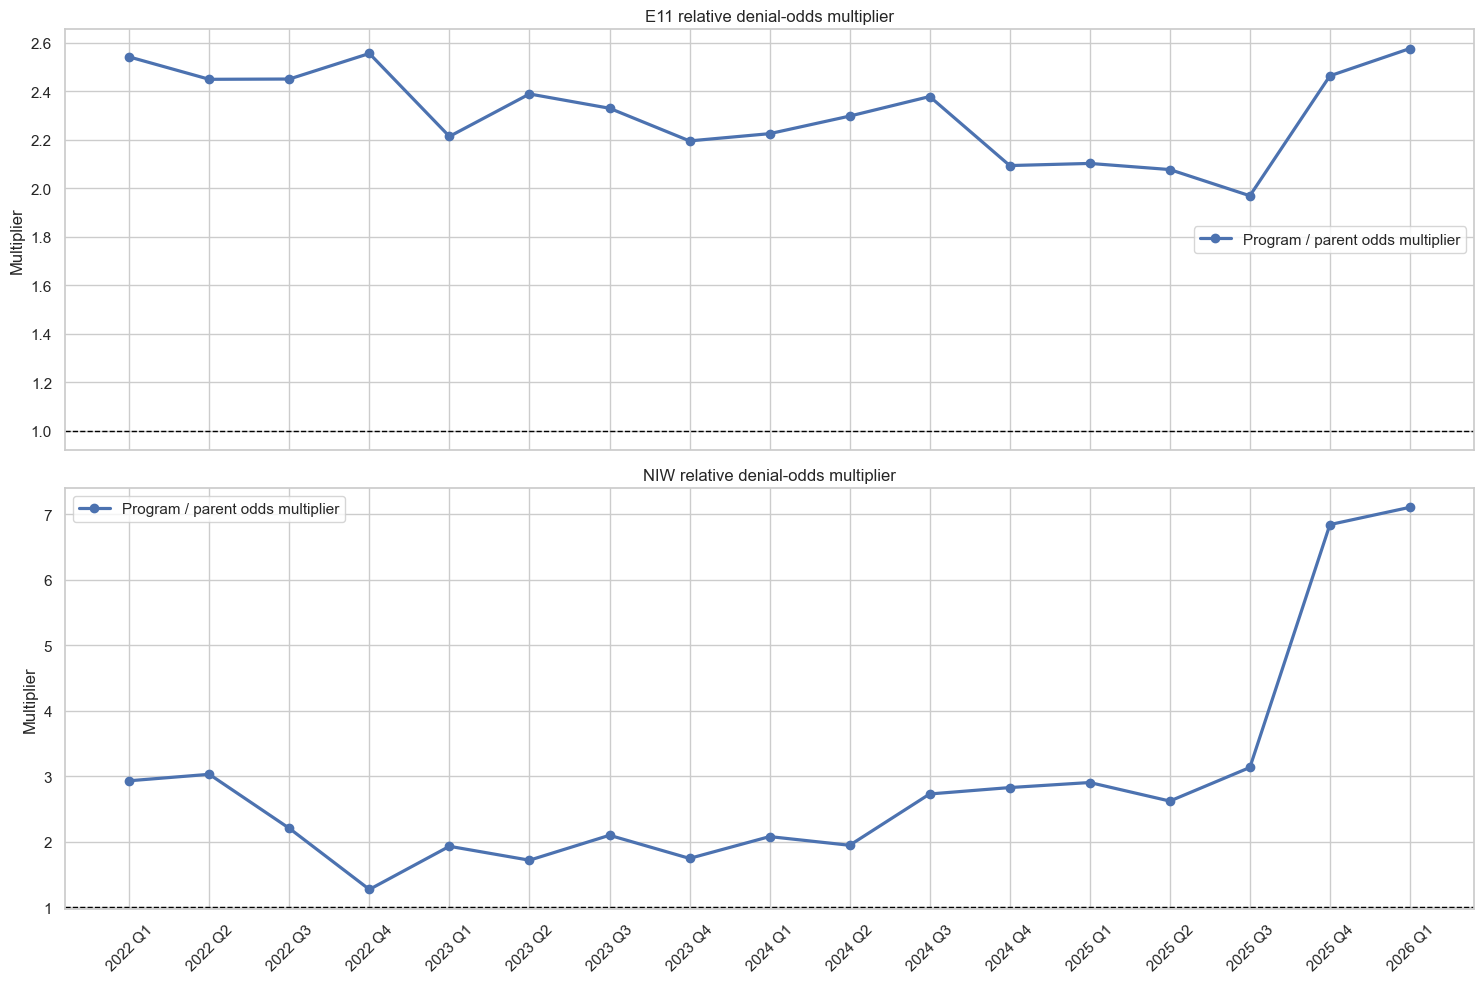

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for ax, program in zip(axes, pairs):
    part = quarterly[quarterly["program"] == program]
    ax.plot(part["period_label"], part["program_odds"], marker="o", linewidth=2.3,
            label=f"{program} denied/approved")
    ax.plot(part["period_label"], part["parent_odds"], marker="o", linewidth=2.1,
            linestyle="--", label=f"{pairs[program]} denied/approved")
    ax.set_title(f"{program} versus {pairs[program]}")
    ax.set_ylabel("Denied / approved")
    ax.legend()

axes[-1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
for ax, program in zip(axes, pairs):
    part = quarterly[quarterly["program"] == program]
    ax.plot(part["period_label"], part["program_parent_multiplier"], marker="o", linewidth=2.3,
            label="Program / parent odds multiplier")
    ax.axhline(1, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{program} relative denial-odds multiplier")
    ax.set_ylabel("Multiplier")
    ax.legend()
axes[-1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 6. Statistical relationship between target-program and parent trends

Three diagnostics are reported:

1. Pearson and Spearman correlation of log denial odds.
2. Regression sensitivity: how strongly program log odds move with parent log odds.
3. Time trend in the program-parent multiplier.

The regression uses HAC standard errors with one lag to reduce sensitivity to short-run autocorrelation. The series is still short, so the results are exploratory.

In [10]:
relationship_rows = []
for program, parent in pairs.items():
    part = quarterly[quarterly["program"] == program].copy().reset_index(drop=True)
    part["time_index"] = np.arange(len(part))
    part["log_program_odds"] = np.log(part["program_odds"])
    part["log_parent_odds"] = np.log(part["parent_odds"])
    part["log_multiplier"] = np.log(part["program_parent_multiplier"])

    pearson = stats.pearsonr(part["log_parent_odds"], part["log_program_odds"])
    spearman = stats.spearmanr(part["log_parent_odds"], part["log_program_odds"])
    sensitivity = sm.OLS(part["log_program_odds"], sm.add_constant(part["log_parent_odds"])).fit(
        cov_type="HAC", cov_kwds={"maxlags": 1}
    )
    multiplier_trend = sm.OLS(part["log_multiplier"], sm.add_constant(part["time_index"])).fit(
        cov_type="HAC", cov_kwds={"maxlags": 1}
    )

    relationship_rows.append({
        "program": program,
        "parent": parent,
        "quarters": len(part),
        "pearson_r": pearson.statistic,
        "pearson_p": pearson.pvalue,
        "spearman_rho": spearman.statistic,
        "spearman_p": spearman.pvalue,
        "parent_sensitivity_beta": sensitivity.params["log_parent_odds"],
        "parent_sensitivity_p": sensitivity.pvalues["log_parent_odds"],
        "regression_r2": sensitivity.rsquared,
        "log_multiplier_trend_per_quarter": multiplier_trend.params["time_index"],
        "multiplier_trend_p": multiplier_trend.pvalues["time_index"],
    })

relationship_tests = pd.DataFrame(relationship_rows)
display(relationship_tests.style.format({
    "pearson_r": "{:.3f}", "pearson_p": "{:.4f}",
    "spearman_rho": "{:.3f}", "spearman_p": "{:.4f}",
    "parent_sensitivity_beta": "{:.3f}", "parent_sensitivity_p": "{:.4f}",
    "regression_r2": "{:.3f}",
    "log_multiplier_trend_per_quarter": "{:+.3f}", "multiplier_trend_p": "{:.4f}",
}))

,program,parent,quarters,pearson_r,pearson_p,spearman_rho,spearman_p,parent_sensitivity_beta,parent_sensitivity_p,regression_r2,log_multiplier_trend_per_quarter,multiplier_trend_p
0,E11,EB1,17,0.980,0.0000,0.936,0.0000,0.979,0.0000,0.961,-0.007,0.1911
1,NIW,EB2,17,0.962,0.0000,0.951,0.0000,1.134,0.0000,0.925,+0.055,0.0402


### Program-parent difference and interval

The table below summarizes the geometric mean program-parent multiplier across quarters. A bootstrap interval resamples quarters.

The pooled formal odds ratio compares the program with the remainder of the parent category, not with the overlapping parent total.

In [11]:
def bootstrap_geomean(values, iterations=5000, seed=42):
    rng = np.random.default_rng(seed)
    logs = np.log(np.asarray(values))
    draws = []
    for _ in range(iterations):
        sample = logs[rng.integers(0, len(logs), len(logs))]
        draws.append(np.exp(sample.mean()))
    return np.quantile(draws, [0.025, 0.975])

program_diff_rows = []
for program, parent in pairs.items():
    part = quarterly[quarterly["program"] == program]
    ci = bootstrap_geomean(part["program_parent_multiplier"])

    pa = part["approved_program"].sum()
    pdn = part["denied_program"].sum()
    ra = (part["approved_parent"] - part["approved_program"]).sum()
    rdn = (part["denied_parent"] - part["denied_program"]).sum()
    pooled_or = (pdn / pa) / (rdn / ra)
    se = np.sqrt(1 / pdn + 1 / pa + 1 / rdn + 1 / ra)

    program_diff_rows.append({
        "program": program,
        "parent": parent,
        "geometric_program_parent_multiplier": np.exp(np.log(part["program_parent_multiplier"]).mean()),
        "bootstrap_ci_low": ci[0],
        "bootstrap_ci_high": ci[1],
        "pooled_or_vs_parent_remainder": pooled_or,
        "pooled_or_ci_low": np.exp(np.log(pooled_or) - 1.96 * se),
        "pooled_or_ci_high": np.exp(np.log(pooled_or) + 1.96 * se),
        "quarters_significant_at_5pct": (part["or_p_value"] < 0.05).sum(),
        "quarters_total": len(part),
    })

program_difference = pd.DataFrame(program_diff_rows)
display(program_difference.style.format({
    "geometric_program_parent_multiplier": "{:.2f}x",
    "bootstrap_ci_low": "{:.2f}x", "bootstrap_ci_high": "{:.2f}x",
    "pooled_or_vs_parent_remainder": "{:.2f}x",
    "pooled_or_ci_low": "{:.2f}x", "pooled_or_ci_high": "{:.2f}x",
}))

,program,parent,geometric_program_parent_multiplier,bootstrap_ci_low,bootstrap_ci_high,pooled_or_vs_parent_remainder,pooled_or_ci_low,pooled_or_ci_high,quarters_significant_at_5pct,quarters_total
0,E11,EB1,2.31x,2.22x,2.39x,10.47x,10.06x,10.90x,17,17
1,NIW,EB2,2.60x,2.15x,3.23x,14.33x,13.95x,14.72x,16,17


## 7. Build the time-varying pending-denial index

The combined index is constructed in log-odds space:

```text
program pending denial odds
    = parent pending-resolution odds trend
    x program-versus-parent odds multiplier trend
```

Two small regressions are used:

- a weighted annual trend for EB1/EB2 pending-resolution odds;
- a quarterly trend for the E11/NIW program-parent multiplier.

The uncertainty interval combines the two model standard errors. This assumes the components are approximately independent, which is a simplifying approximation.

In [12]:
def logit_from_odds(odds):
    return odds / (1 + odds)

combined_parts = []
parent_models = {}
multiplier_models = {}

for program, parent in pairs.items():
    annual = maturity[maturity["type"] == parent].sort_values("fiscal_year").copy()
    annual["year_centered"] = annual["fiscal_year"] - annual["fiscal_year"].min()
    annual["log_pending_odds"] = np.log(annual["pending_denial_approval_ratio"])
    parent_model = sm.WLS(
        annual["log_pending_odds"],
        sm.add_constant(annual["year_centered"]),
        weights=annual["resolved_from_pending"],
    ).fit()
    parent_models[parent] = parent_model

    q = quarterly[quarterly["program"] == program].sort_values("period").copy().reset_index(drop=True)
    q["time_index"] = np.arange(len(q))
    q["log_multiplier"] = np.log(q["program_parent_multiplier"])
    multiplier_model = sm.OLS(q["log_multiplier"], sm.add_constant(q["time_index"])).fit()
    multiplier_models[program] = multiplier_model

    year_x = q["fiscal_year"] - annual["fiscal_year"].min()
    parent_exog = sm.add_constant(pd.Series(year_x, name="year_centered"), has_constant="add")
    parent_pred = parent_model.get_prediction(parent_exog).summary_frame()

    mult_exog = sm.add_constant(q[["time_index"]], has_constant="add")
    multiplier_pred = multiplier_model.get_prediction(mult_exog).summary_frame()

    q["parent_pending_log_odds_trend"] = parent_pred["mean"].to_numpy()
    q["parent_pending_log_odds_se"] = parent_pred["mean_se"].to_numpy()
    q["program_multiplier_log_trend"] = multiplier_pred["mean"].to_numpy()
    q["program_multiplier_log_se"] = multiplier_pred["mean_se"].to_numpy()

    q["forecast_pending_log_odds"] = q["parent_pending_log_odds_trend"] + q["program_multiplier_log_trend"]
    q["forecast_pending_log_odds_se"] = np.sqrt(
        q["parent_pending_log_odds_se"] ** 2 + q["program_multiplier_log_se"] ** 2
    )
    q["forecast_pending_denial_odds"] = np.exp(q["forecast_pending_log_odds"])
    q["forecast_pending_denial_share"] = logit_from_odds(q["forecast_pending_denial_odds"])
    q["forecast_pending_denial_share_low"] = logit_from_odds(
        np.exp(q["forecast_pending_log_odds"] - 1.96 * q["forecast_pending_log_odds_se"])
    )
    q["forecast_pending_denial_share_high"] = logit_from_odds(
        np.exp(q["forecast_pending_log_odds"] + 1.96 * q["forecast_pending_log_odds_se"])
    )
    q["forecast_pending_denied"] = q["pending_program"] * q["forecast_pending_denial_share"]
    q["forecast_pending_approved"] = q["pending_program"] - q["forecast_pending_denied"]
    combined_parts.append(q)

combined_index = pd.concat(combined_parts, ignore_index=True).sort_values(["program", "period"])
display(combined_index[[
    "program", "period_label", "program_denial_share", "parent_denial_share",
    "program_parent_multiplier", "forecast_pending_denial_share",
    "forecast_pending_denial_share_low", "forecast_pending_denial_share_high",
    "pending_program", "forecast_pending_approved", "forecast_pending_denied",
]].tail(8).style.format({
    "program_denial_share": "{:.1%}", "parent_denial_share": "{:.1%}",
    "program_parent_multiplier": "{:.2f}x",
    "forecast_pending_denial_share": "{:.1%}",
    "forecast_pending_denial_share_low": "{:.1%}",
    "forecast_pending_denial_share_high": "{:.1%}",
    "forecast_pending_approved": "{:,.0f}", "forecast_pending_denied": "{:,.0f}",
}))

,program,period_label,program_denial_share,parent_denial_share,program_parent_multiplier,forecast_pending_denial_share,forecast_pending_denial_share_low,forecast_pending_denial_share_high,pending_program,forecast_pending_approved,forecast_pending_denied
26,NIW,2024 Q2,24.2%,14.1%,1.95x,57.9%,43.9%,70.7%,28694,"12,091","16,603"
27,NIW,2024 Q3,31.8%,14.6%,2.73x,59.2%,45.2%,71.8%,34118,"13,925","20,193"
28,NIW,2024 Q4,38.8%,18.3%,2.83x,60.5%,46.4%,73.0%,44093,"17,418","26,675"
29,NIW,2025 Q1,37.3%,17.0%,2.91x,65.7%,48.1%,79.9%,56611,"19,414","37,197"
30,NIW,2025 Q2,32.7%,15.6%,2.62x,66.9%,49.2%,80.9%,64475,"21,326","43,149"
31,NIW,2025 Q3,46.0%,21.4%,3.14x,68.1%,50.4%,81.8%,68821,"21,940","46,881"
32,NIW,2025 Q4,64.3%,20.9%,6.84x,69.3%,51.5%,82.8%,74392,"22,843","51,549"
33,NIW,2026 Q1,57.4%,15.9%,7.11x,73.8%,52.7%,87.7%,82812,"21,661","61,151"


## 8. Main forecast chart

For each target program:

- **solid line**: observed denial share among already decided quarterly RADP outcomes;
- **dashed line**: modeled denial share for currently pending inventory;
- shaded band: approximate 95% model interval.

The dashed line should not be interpreted as the final denial rate for petitions received in the same quarter. RADP pending is an inventory stock, not a clean filing cohort.

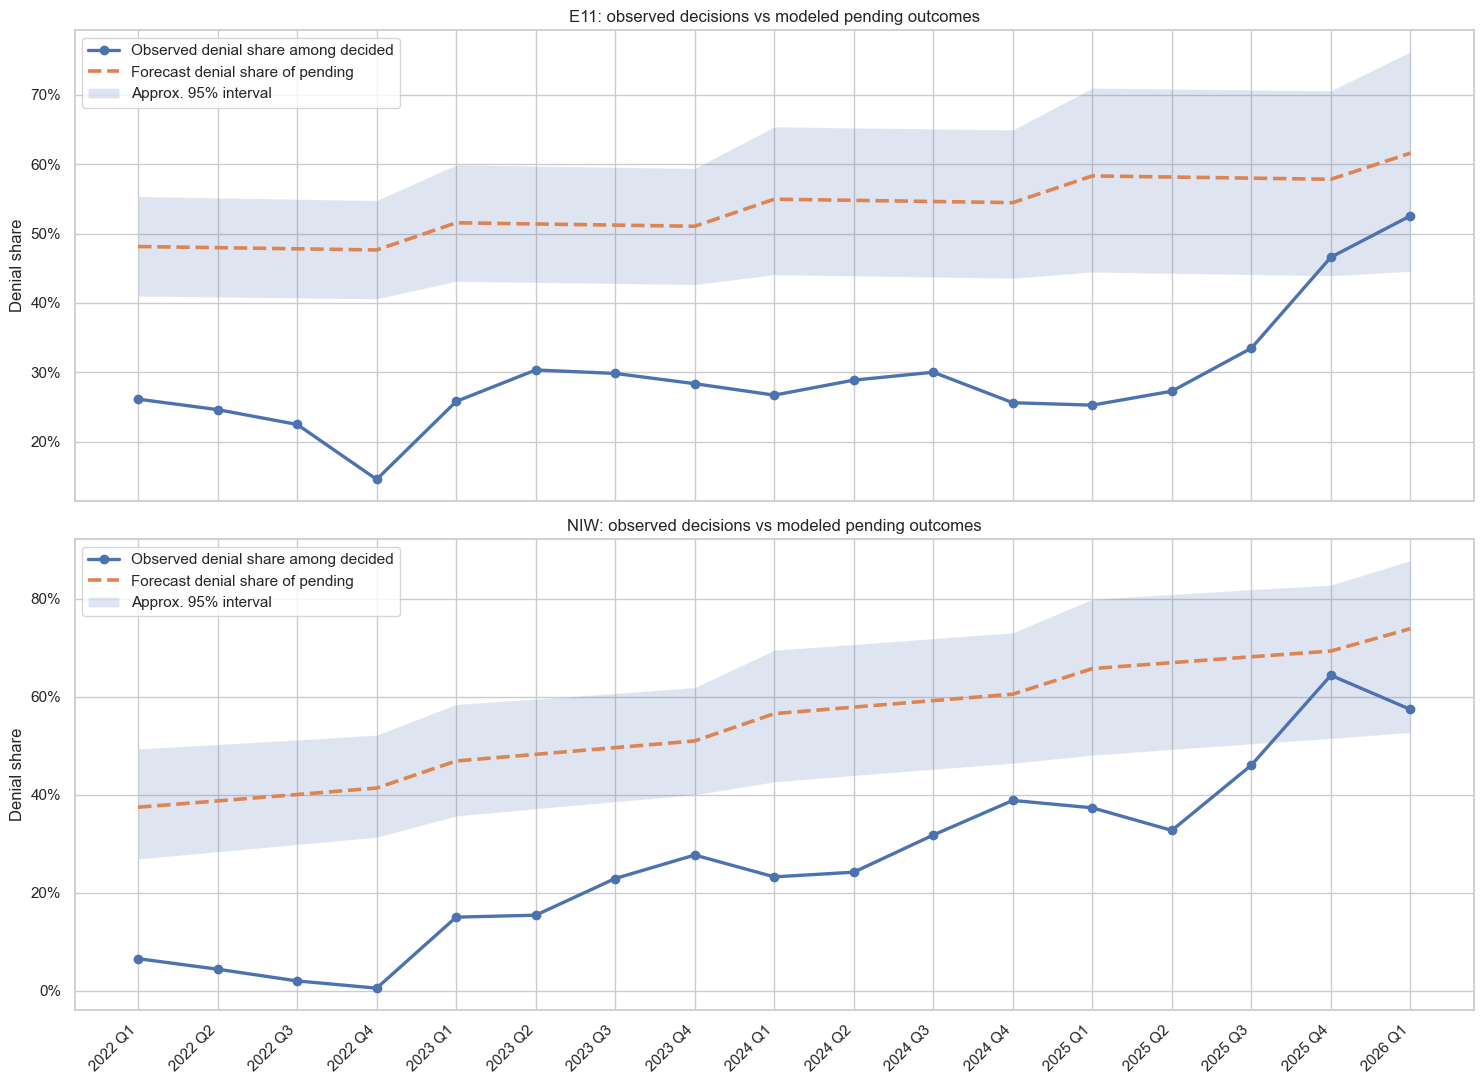

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(15, 11), sharex=True)

for ax, program in zip(axes, pairs):
    part = combined_index[combined_index["program"] == program].copy()
    x = np.arange(len(part))
    ax.plot(x, part["program_denial_share"], marker="o", linewidth=2.4,
            label="Observed denial share among decided")
    ax.plot(x, part["forecast_pending_denial_share"], linewidth=2.6, linestyle="--",
            label="Forecast denial share of pending")
    ax.fill_between(
        x,
        part["forecast_pending_denial_share_low"].to_numpy(float),
        part["forecast_pending_denial_share_high"].to_numpy(float),
        alpha=0.18,
        label="Approx. 95% interval",
    )
    ax.set_title(f"{program}: observed decisions vs modeled pending outcomes")
    ax.set_ylabel("Denial share")
    ax.yaxis.set_major_formatter(lambda v, pos: f"{v:.0%}")
    ax.legend()

axes[-1].set_xticks(np.arange(len(part)))
axes[-1].set_xticklabels(part["period_label"], rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Current pending allocation and the practical correction number

The most practical output is the latest modeled pending-denial share for E11 and NIW.

It can be used as follows:

```text
expected denied from pending   = pending inventory x modeled denial share
expected approved from pending = pending inventory x (1 - modeled denial share)
```

This allocation is a scenario estimate, not a count of specific petitions that will receive each outcome.

,program,parent,latest_period,pending_inventory,parent_pooled_pending_denial_share,program_parent_geometric_multiplier,modeled_pending_denial_share,modeled_share_ci_low,modeled_share_ci_high,expected_approved_from_pending,expected_denied_from_pending
0,E11,EB1,2026 Q1,"24,653",27.5%,2.31x,61.6%,44.5%,76.2%,"9,471","15,182"
1,NIW,EB2,2026 Q1,"82,812",27.6%,2.60x,73.8%,52.7%,87.7%,"21,661","61,151"


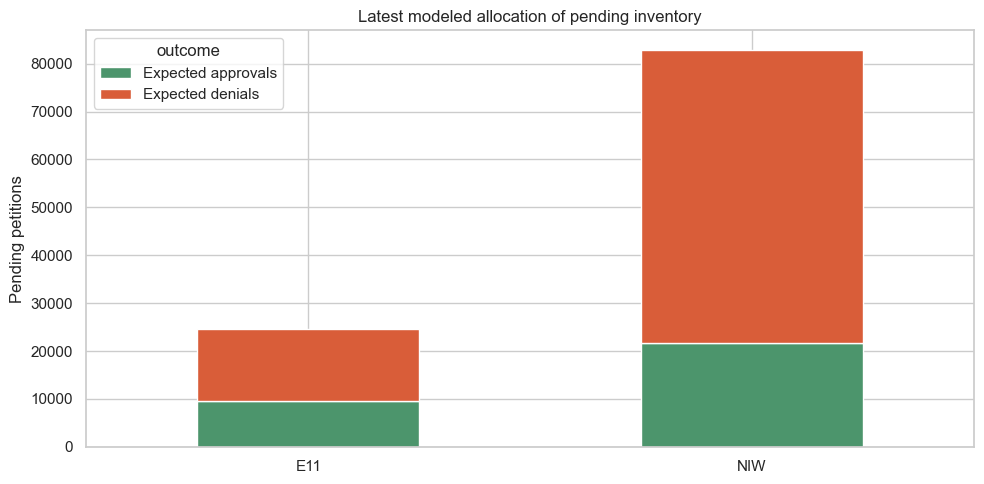

In [14]:
latest_rows = []
for program, parent in pairs.items():
    latest = combined_index[combined_index["program"] == program].sort_values("period").iloc[-1]
    parent_corr = parent_correction[parent_correction["parent"] == parent].iloc[0]
    program_diff = program_difference[program_difference["program"] == program].iloc[0]
    latest_rows.append({
        "program": program,
        "parent": parent,
        "latest_period": latest["period_label"],
        "pending_inventory": latest["pending_program"],
        "parent_pooled_pending_denial_share": parent_corr["pending_denial_share"],
        "program_parent_geometric_multiplier": program_diff["geometric_program_parent_multiplier"],
        "modeled_pending_denial_share": latest["forecast_pending_denial_share"],
        "modeled_share_ci_low": latest["forecast_pending_denial_share_low"],
        "modeled_share_ci_high": latest["forecast_pending_denial_share_high"],
        "expected_approved_from_pending": latest["forecast_pending_approved"],
        "expected_denied_from_pending": latest["forecast_pending_denied"],
    })

latest_forecast = pd.DataFrame(latest_rows)
display(latest_forecast.style.format({
    "pending_inventory": "{:,.0f}",
    "parent_pooled_pending_denial_share": "{:.1%}",
    "program_parent_geometric_multiplier": "{:.2f}x",
    "modeled_pending_denial_share": "{:.1%}",
    "modeled_share_ci_low": "{:.1%}",
    "modeled_share_ci_high": "{:.1%}",
    "expected_approved_from_pending": "{:,.0f}",
    "expected_denied_from_pending": "{:,.0f}",
}))

allocation = latest_forecast.melt(
    id_vars=["program"],
    value_vars=["expected_approved_from_pending", "expected_denied_from_pending"],
    var_name="outcome",
    value_name="count",
)
allocation["outcome"] = allocation["outcome"].map({
    "expected_approved_from_pending": "Expected approvals",
    "expected_denied_from_pending": "Expected denials",
})

fig, ax = plt.subplots(figsize=(10, 5))
pivot = allocation.pivot(index="program", columns="outcome", values="count")
pivot[["Expected approvals", "Expected denials"]].plot(kind="bar", stacked=True, ax=ax,
                                                         color=["#4c956c", "#d95d39"])
ax.set_title("Latest modeled allocation of pending inventory")
ax.set_xlabel("")
ax.set_ylabel("Pending petitions")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 10. Exploratory four-quarter trend extrapolation

It is possible to extrapolate the observed E11/NIW denial-odds trend, but the result must be treated cautiously:

- only FY2022-FY2026 Q1 is available;
- quarterly observations are autocorrelated;
- FY2026 may represent a structural break;
- a linear log-odds model cannot capture policy changes or future workload shocks.

The following chart is therefore a sensitivity scenario, not a production forecast.

,program,log_odds_change_per_quarter,trend_p_value_HAC,r_squared
0,E11,+0.055,0.0075,0.462
1,NIW,+0.252,0.0000,0.721


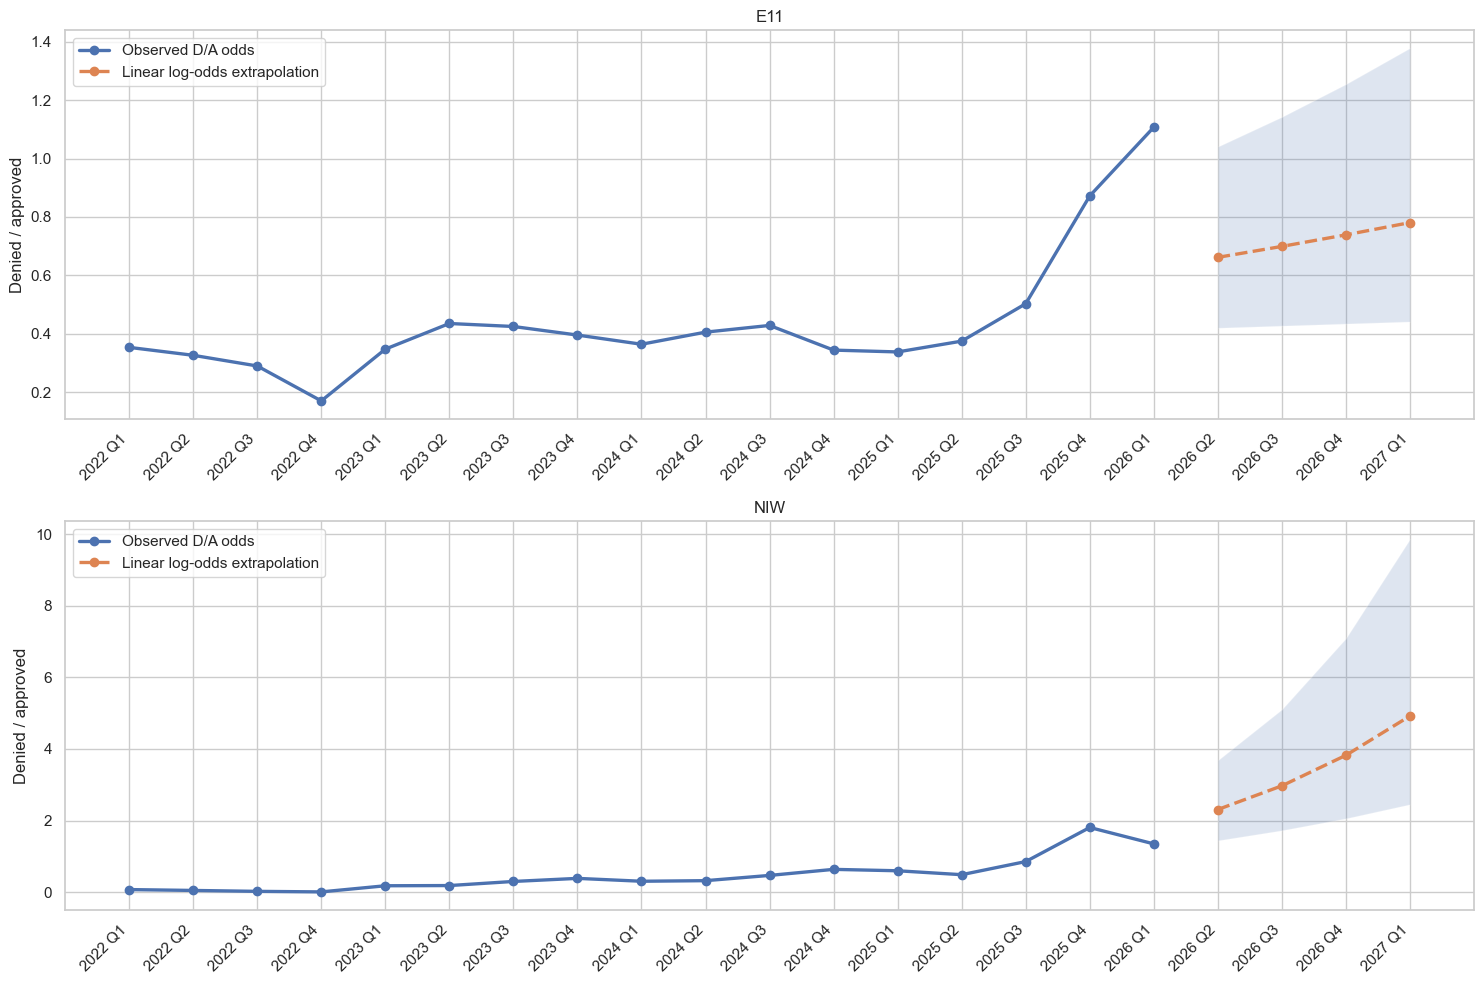

In [15]:
future_parts = []
trend_rows = []

for program in pairs:
    part = quarterly[quarterly["program"] == program].sort_values("period").copy().reset_index(drop=True)
    part["time_index"] = np.arange(len(part))
    part["log_program_odds"] = np.log(part["program_odds"])
    model = sm.OLS(part["log_program_odds"], sm.add_constant(part[["time_index"]])).fit(
        cov_type="HAC", cov_kwds={"maxlags": 1}
    )

    future_t = np.arange(len(part), len(part) + 4)
    future_exog = sm.add_constant(pd.DataFrame({"time_index": future_t}), has_constant="add")
    pred = model.get_prediction(future_exog).summary_frame()
    last_period = part["period"].iloc[-1]

    future = pd.DataFrame({
        "program": program,
        "period": [last_period + i for i in range(1, 5)],
        "time_index": future_t,
        "odds_forecast": np.exp(pred["mean"].to_numpy()),
        "odds_ci_low": np.exp(pred["mean_ci_lower"].to_numpy()),
        "odds_ci_high": np.exp(pred["mean_ci_upper"].to_numpy()),
    })
    future["period_label"] = future["period"].astype(str).str.replace("Q", " Q", regex=False)
    future_parts.append(future)
    trend_rows.append({
        "program": program,
        "log_odds_change_per_quarter": model.params["time_index"],
        "trend_p_value_HAC": model.pvalues["time_index"],
        "r_squared": model.rsquared,
    })

future_trend = pd.concat(future_parts, ignore_index=True)
trend_tests = pd.DataFrame(trend_rows)
display(trend_tests.style.format({
    "log_odds_change_per_quarter": "{:+.3f}",
    "trend_p_value_HAC": "{:.4f}",
    "r_squared": "{:.3f}",
}))

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
for ax, program in zip(axes, pairs):
    hist = quarterly[quarterly["program"] == program].sort_values("period")
    fut = future_trend[future_trend["program"] == program]
    x_hist = np.arange(len(hist))
    x_future = np.arange(len(hist), len(hist) + len(fut))
    ax.plot(x_hist, hist["program_odds"], marker="o", linewidth=2.4, label="Observed D/A odds")
    ax.plot(x_future, fut["odds_forecast"], marker="o", linestyle="--", linewidth=2.4,
            label="Linear log-odds extrapolation")
    ax.fill_between(x_future, fut["odds_ci_low"].to_numpy(float), fut["odds_ci_high"].to_numpy(float), alpha=0.18)
    labels = hist["period_label"].tolist() + fut["period_label"].tolist()
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_title(program)
    ax.set_ylabel("Denied / approved")
    ax.legend()
plt.tight_layout()
plt.show()

## 11. Conclusions and recommended interpretation

### What this notebook measures reasonably well

1. The actual-to-historic yearly snapshots provide a direct aggregate estimate of how EB1/EB2 pending inventory later split into approvals and denials.
2. E11 and NIW quarterly denial odds can be compared with EB1 and EB2 over the same periods.
3. The combined odds index gives a transparent, time-varying correction for current E11/NIW pending inventory.

### What remains uncertain

1. E11/NIW pending is not cohort-tracked; it is an inventory stock.
2. EB1 and EB2 parent maturation can differ from E11 and NIW maturation for reasons not captured by the multiplier.
3. USCIS revises historical counts, which creates small reconciliation gaps.
4. The available paired yearly sample begins in FY2019 and the detailed quarterly sample begins in FY2022.
5. RFE, premium processing, filing quality, policy changes, and adjudicator mix are not directly observed.

### Recommended use

- Treat the latest modeled pending-denial share as a scenario range, not a single certain probability.
- Re-run the notebook after every new USCIS quarter.
- Track whether the program-parent multiplier remains stable or shifts structurally.
- Backtest each forecast once a new historic snapshot becomes available.
- Prefer the interval and scenario outputs over a point estimate when communicating with clients.